In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
zip_ref=zipfile.ZipFile('/content/brain-tumor-mri-dataset.zip','r')
zip_ref.extractall("/content")
zip_ref.close()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory="/content/Training",
    seed=123,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(512,512)
)

Found 5712 files belonging to 4 classes.


In [ ]:
validation_ds = tf.keras.utils.image_dataset_from_directory(
    directory="/content/Testing",
    seed=123,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(512,512)
)

Found 1311 files belonging to 4 classes.


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


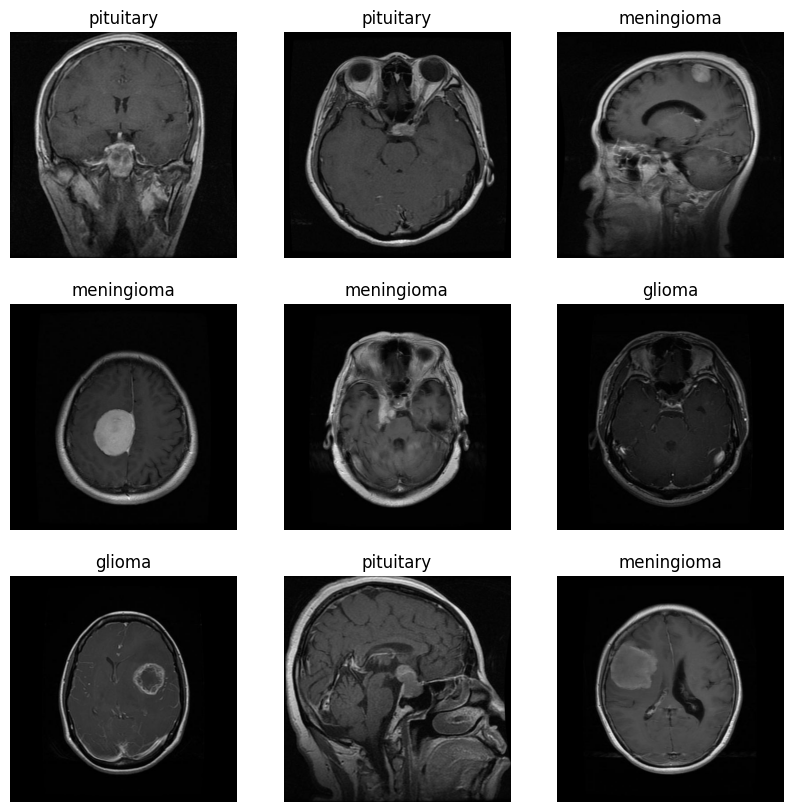

In [ ]:
class_names = train_ds.class_names
print("Classes:", class_names)

# Preview some images
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [ ]:
##Normalize
def process(image,label):
  image=tf.cast(image/255,tf.float32)
  return image,label
train_ds=train_ds.map(process)
val_ds=validation_ds.map(process)

In [ ]:
##cnn model
model=Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding="valid",activation='relu',input_shape=(512,512,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(4,activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 510, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 510, 510, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 253, 253, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 124, 124, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 492032)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │    62,980,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,082,884 (240.64 MB)

 Trainable params: 63,082,436 (240.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_ds,epochs=10,validation_data=val_ds,callbacks=[early_stop])

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 63s 308ms/step - accuracy: 0.6373 - loss: 2.5574 - val_accuracy: 0.2288 - val_loss: 21.3098
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 75s 289ms/step - accuracy: 0.7907 - loss: 0.6888 - val_accuracy: 0.3089 - val_loss: 9.9064
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 51s 287ms/step - accuracy: 0.8570 - loss: 0.4512 - val_accuracy: 0.7262 - val_loss: 0.8634
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 81s 279ms/step - accuracy: 0.8867 - loss: 0.3473 - val_accuracy: 0.8924 - val_loss: 0.3288
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 51s 286ms/step - accuracy: 0.9169 - loss: 0.2517 - val_accuracy: 0.9153 - val_loss: 0.3274
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 81s 279ms/step - accuracy: 0.9284 - loss: 0.2471 - val_accuracy: 0.9123 - val_loss: 0.2869
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 84s 291ms/step - accuracy: 0.9425 - loss: 0.1840 - val_accuracy: 0.9451 - val_loss: 0.2148
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 50s 276ms/step - accuracy: 0.9541 - loss: 

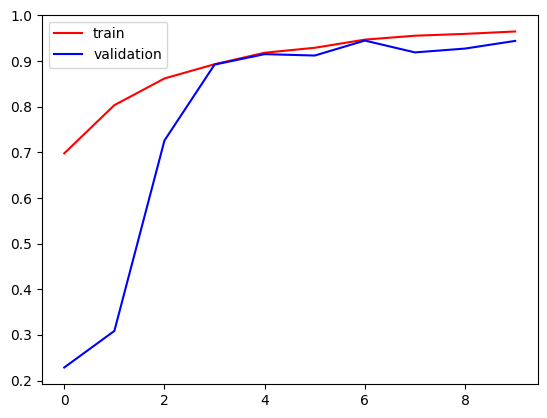

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

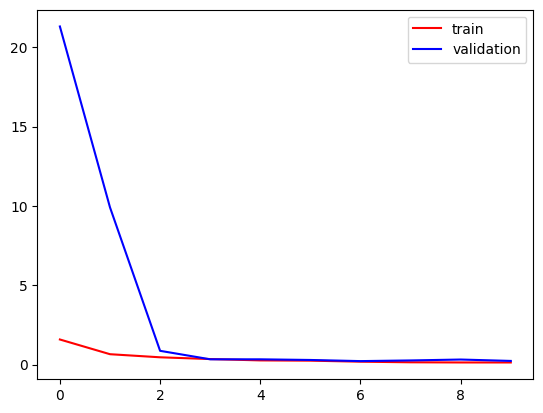

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
import cv2

In [ ]:
test_img=cv2.imread('/content/Screenshot 2025-06-03 201202.png')

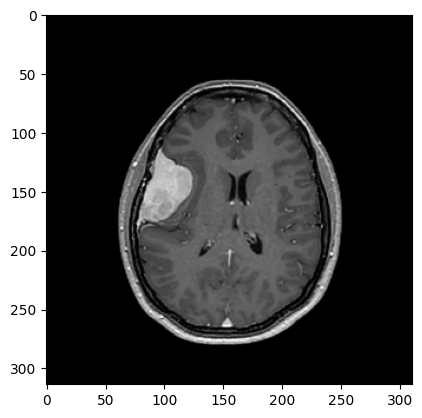

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img=cv2.resize(test_img,(512,512))
test_img=test_img/255


In [ ]:
test_input=test_img.reshape(1,512,512,3)

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[0.17423746, 0.4648414 , 0.20630431, 0.15461677]], dtype=float32)